<a href="https://colab.research.google.com/github/AnmolChetani/pricelens-ai/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# !git clone https://github.com/AnmolChetani/pricelens-ai.git

Cloning into 'pricelens-ai'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 60 (delta 27), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 164.34 KiB | 1.34 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [3]:
# %cd pricelens-ai

/content/pricelens-ai


In [4]:
# !ls

app  notebooks	README.md  requirements.txt  saved_models  src


In [5]:
# !git config --global user.name "AnmolChetani"
# !git config --global user.email "anmolchetani@gmail.com"

In [6]:
# !mkdir -p notebooks

In [7]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Utility
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [49]:

# Use python engine + skip bad lines
train_df = pd.read_csv(
    "/content/sample_data/train.csv",
    engine='python',
    on_bad_lines='skip'
)

test_df = pd.read_csv(
    "/content/sample_data/test.csv",
    engine='python',
    on_bad_lines='skip'
)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (75000, 4)
Test shape: (75000, 3)


In [50]:
train_df.head()

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [51]:
test_df.head()

,sample_id,catalog_content,image_link
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...


In [52]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB


In [53]:
train_df.isnull().sum()

,0
sample_id,0
catalog_content,0
image_link,0
price,0


In [54]:
test_df.isnull().sum()

,0
sample_id,0
catalog_content,0
image_link,0


In [55]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [57]:
train_df["price"].describe()

,price
count,75000.000000
mean,23.647654
std,33.376932
min,0.130000
25%,6.795000
50%,14.000000
75%,28.625000
max,2796.000000


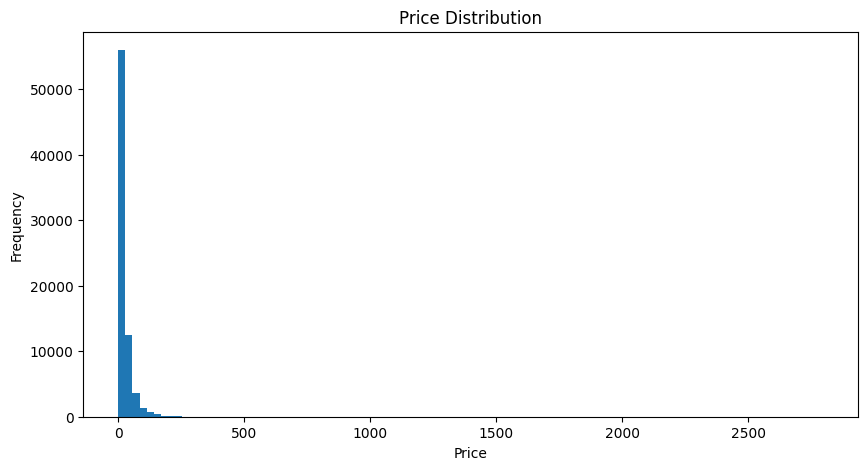

In [58]:
plt.figure(figsize=(10,5))

plt.hist(train_df["price"], bins=100)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")

plt.show()

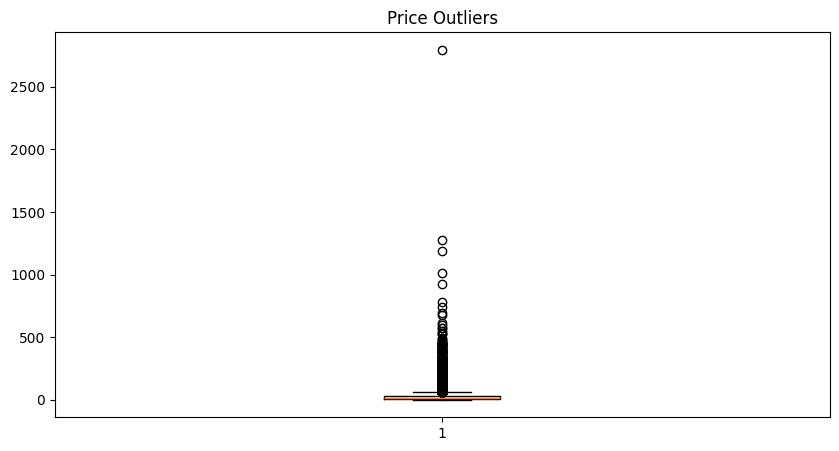

In [59]:
plt.figure(figsize=(10,5))

plt.boxplot(train_df["price"])

plt.title("Price Outliers")
plt.show()

In [60]:
for i in range(5):
    print(f"\nProduct {i+1}")
    print(train_df["catalog_content"].iloc[i])
    print("-" * 100)


Product 1
Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)
Value: 72.0
Unit: Fl Oz

----------------------------------------------------------------------------------------------------

Product 2
Item Name: Salerno Cookies, The Original Butter Cookies, 8 Ounce (Pack of 4)
Bullet Point 1: Original Butter Cookies: Classic butter cookies made with real butter
Bullet Point 2: Variety Pack: Includes 4 boxes with 32 cookies total
Bullet Point 3: Occasion Perfect: Delicious cookies for birthdays, weddings, anniversaries
Bullet Point 4: Shareable Treats: Fun to give and enjoy with friends and family
Bullet Point 5: Salerno Brand: Trusted brand of delicious butter cookies since 1925
Value: 32.0
Unit: Ounce

----------------------------------------------------------------------------------------------------

Product 3
Item Name: Bear Creek Hearty Soup Bowl, Creamy Chicken with Rice, 1.9 Ounce (Pack of 6)
Bullet Point 1: Loaded with hearty long grain wild rice and vegetables
Bu

In [61]:
train_df["text_length"] = train_df["catalog_content"].apply(len)

train_df["text_length"].describe()

,text_length
count,75000.000000
mean,908.886547
std,852.896151
min,32.000000
25%,251.000000
50%,643.000000
75%,1280.000000
max,7894.000000


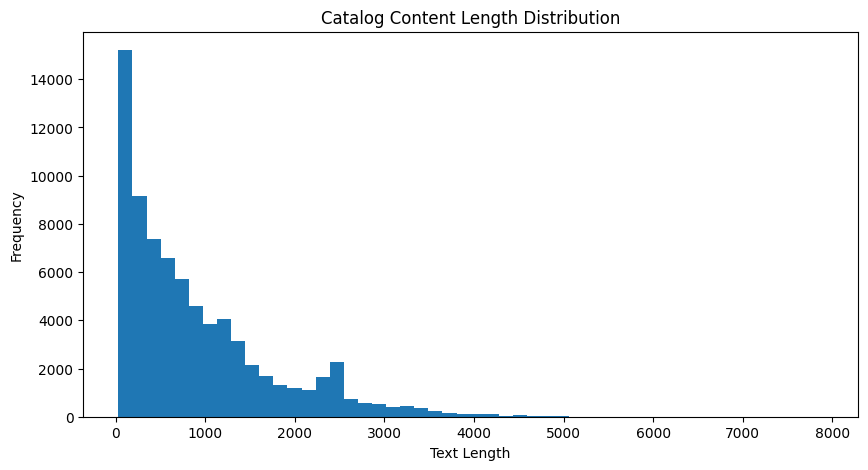

In [62]:
plt.figure(figsize=(10,5))

plt.hist(train_df["text_length"], bins=50)

plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Catalog Content Length Distribution")

plt.show()

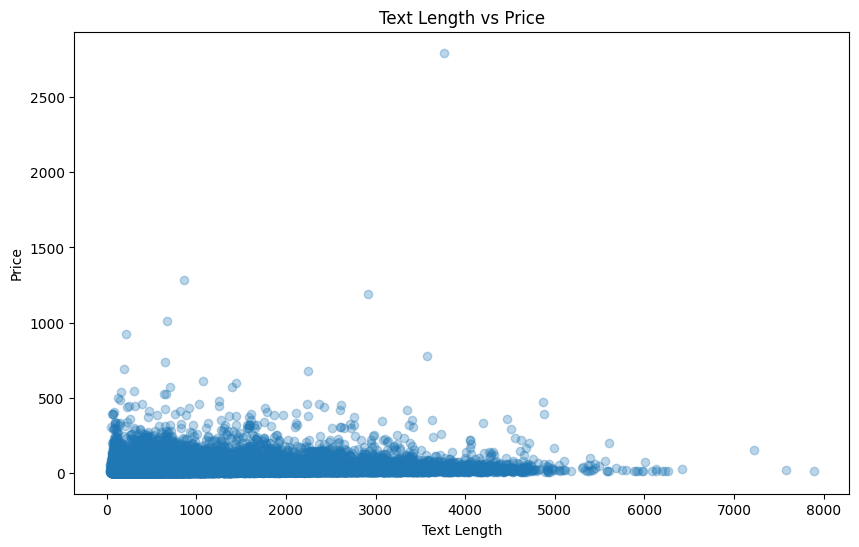

In [63]:
plt.figure(figsize=(10,6))

plt.scatter(
    train_df["text_length"],
    train_df["price"],
    alpha=0.3
)

plt.xlabel("Text Length")
plt.ylabel("Price")
plt.title("Text Length vs Price")

plt.show()

In [64]:
train_df[["text_length", "price"]].corr()

,text_length,price
text_length,1.000000,0.146752
price,0.146752,1.000000


In [65]:
import re

def extract_numbers(text):
    numbers = re.findall(r'\d+\.?\d*', text)
    return len(numbers)

train_df["num_count"] = train_df["catalog_content"].apply(extract_numbers)

train_df["num_count"].describe()

,num_count
count,75000.000000
mean,8.854707
std,5.189912
min,0.000000
25%,5.000000
50%,9.000000
75%,11.000000
max,89.000000


In [66]:
train_df[["num_count", "price"]].corr()

,num_count,price
num_count,1.000000,0.138371
price,0.138371,1.000000


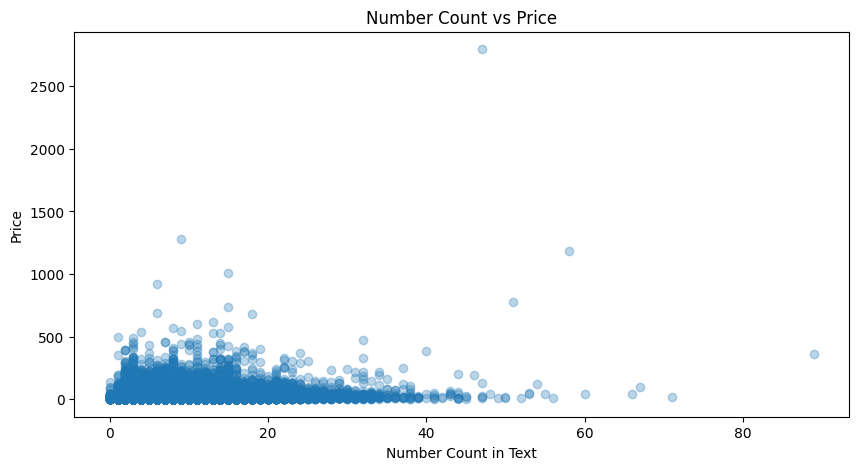

In [67]:
plt.figure(figsize=(10,5))

plt.scatter(
    train_df["num_count"],
    train_df["price"],
    alpha=0.3
)

plt.xlabel("Number Count in Text")
plt.ylabel("Price")
plt.title("Number Count vs Price")

plt.show()

In [68]:
import re

def extract_pack_size(text):
    text = str(text).lower()

    match = re.search(r'pack of (\d+)', text)
    if match:
        return int(match.group(1))

    match = re.search(r'(\d+)\s*per case', text)
    if match:
        return int(match.group(1))

    return 1

train_df["pack_size"] = train_df["catalog_content"].apply(extract_pack_size)

In [69]:
train_df["pack_size"].describe()

,pack_size
count,75000.000000
mean,4.128253
std,27.523010
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,2424.000000


In [70]:
train_df["pack_size"].value_counts().head(20)

,count
pack_size,
1,56172
6,4579
12,3831
2,2286
3,1980
4,1733
24,916
8,833
10,408


In [71]:
train_df[["pack_size", "price"]].corr()

,pack_size,price
pack_size,1.000000,0.073142
price,0.073142,1.000000


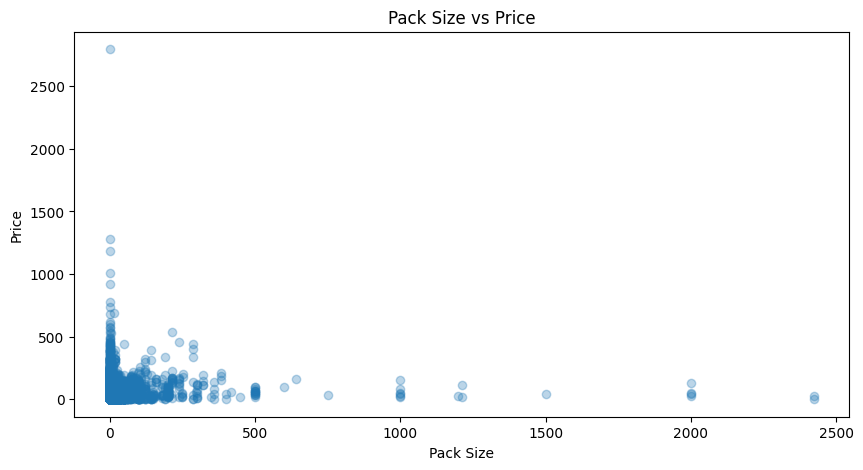

In [72]:
plt.figure(figsize=(10,5))

plt.scatter(
    train_df["pack_size"],
    train_df["price"],
    alpha=0.3
)

plt.xlabel("Pack Size")
plt.ylabel("Price")
plt.title("Pack Size vs Price")

plt.show()

In [73]:
from collections import Counter
import re

# Combine all text
all_text = " ".join(train_df["catalog_content"].astype(str))

# Extract words
words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

# Remove very short words
words = [word for word in words if len(word) > 2]

# Count frequency
word_counts = Counter(words)

# Top 30 words
word_counts.most_common(30)

[('and', 338031),
 ('point', 267979),
 ('bullet', 267690),
 ('the', 241020),
 ('for', 143792),
 ('with', 142500),
 ('our', 83197),
 ('your', 80939),
 ('value', 78935),
 ('item', 77872),
 ('name', 76467),
 ('unit', 75623),
 ('you', 70606),
 ('tea', 70090),
 ('are', 66831),
 ('ounce', 64031),
 ('free', 62220),
 ('flavor', 55513),
 ('that', 52420),
 ('pack', 44828),
 ('product', 44400),
 ('coffee', 42904),
 ('from', 39496),
 ('taste', 38921),
 ('natural', 38347),
 ('this', 37975),
 ('organic', 34423),
 ('all', 33629),
 ('perfect', 33155),
 ('description', 32985)]

In [74]:
cheap_products = train_df[
    train_df["price"] <= train_df["price"].quantile(0.25)
]

expensive_products = train_df[
    train_df["price"] >= train_df["price"].quantile(0.75)
]

print(cheap_products.shape)
print(expensive_products.shape)

(18751, 7)
(18751, 7)


In [75]:
expensive_text = " ".join(
    expensive_products["catalog_content"].astype(str)
)

expensive_words = re.findall(
    r'\b[a-zA-Z]+\b',
    expensive_text.lower()
)

expensive_words = [
    word for word in expensive_words
    if len(word) > 2
]

Counter(expensive_words).most_common(30)

[('and', 121103),
 ('the', 90758),
 ('point', 70033),
 ('bullet', 69945),
 ('with', 46049),
 ('for', 44796),
 ('tea', 34864),
 ('our', 32317),
 ('you', 25057),
 ('your', 24674),
 ('are', 24363),
 ('value', 20134),
 ('that', 19932),
 ('item', 19523),
 ('name', 19211),
 ('unit', 18866),
 ('flavor', 17048),
 ('natural', 17041),
 ('free', 15766),
 ('taste', 14973),
 ('coffee', 14888),
 ('water', 14159),
 ('product', 13675),
 ('ounce', 13572),
 ('pack', 13470),
 ('from', 12861),
 ('all', 12648),
 ('into', 12562),
 ('ingredients', 12535),
 ('quality', 11687)]

In [76]:
cheap_text = " ".join(
    cheap_products["catalog_content"].astype(str)
)

cheap_words = re.findall(
    r'\b[a-zA-Z]+\b',
    cheap_text.lower()
)

cheap_words = [
    word for word in cheap_words
    if len(word) > 2
]

Counter(cheap_words).most_common(30)

[('point', 59433),
 ('bullet', 59403),
 ('and', 43598),
 ('the', 27336),
 ('with', 22689),
 ('for', 20022),
 ('item', 19581),
 ('value', 19410),
 ('unit', 18943),
 ('name', 18900),
 ('ounce', 18459),
 ('free', 11744),
 ('your', 10982),
 ('pack', 10570),
 ('flavor', 8477),
 ('you', 8345),
 ('our', 7819),
 ('are', 7397),
 ('product', 7160),
 ('made', 6633),
 ('organic', 6219),
 ('gluten', 5975),
 ('that', 5871),
 ('delicious', 5412),
 ('this', 5380),
 ('description', 5190),
 ('perfect', 5080),
 ('from', 4802),
 ('chocolate', 4707),
 ('taste', 4699)]

In [77]:
custom_stopwords = {
    'bullet', 'point', 'item',
    'name', 'value', 'unit',
    'description', 'product',
    'and','the','with','for',
    'our','your','you','are',
    'that','from',  'all',
    'will','can','make',
    'enjoy','this','into',
    'perfect'
}

def clean_words(text):
    words = re.findall(
        r'\b[a-zA-Z]+\b',
        str(text).lower()
    )

    words = [
        word for word in words
        if len(word) > 2
        and word not in custom_stopwords
    ]

    return words

In [78]:
expensive_clean = []

for text in expensive_products["catalog_content"]:
    expensive_clean.extend(clean_words(text))

Counter(expensive_clean).most_common(30)

[('tea', 34864),
 ('flavor', 17048),
 ('natural', 17041),
 ('free', 15766),
 ('taste', 14973),
 ('coffee', 14888),
 ('water', 14159),
 ('ounce', 13572),
 ('pack', 13470),
 ('ingredients', 12535),
 ('quality', 11687),
 ('products', 10511),
 ('organic', 9716),
 ('delicious', 8965),
 ('chocolate', 8765),
 ('terravita', 8696),
 ('pour', 8387),
 ('count', 7954),
 ('made', 7710),
 ('bags', 7505),
 ('cup', 7364),
 ('cold', 7362),
 ('each', 7262),
 ('highest', 7050),
 ('add', 6974),
 ('sugar', 6952),
 ('certified', 6900),
 ('flavors', 6860),
 ('use', 6774),
 ('gluten', 6555)]

In [79]:
cheap_clean = []

for text in cheap_products["catalog_content"]:
    cheap_clean.extend(clean_words(text))

Counter(cheap_clean).most_common(30)

[('ounce', 18459),
 ('free', 11744),
 ('pack', 10570),
 ('flavor', 8477),
 ('made', 6633),
 ('organic', 6219),
 ('gluten', 5975),
 ('delicious', 5412),
 ('chocolate', 4707),
 ('taste', 4699),
 ('flavors', 4672),
 ('snack', 4631),
 ('ingredients', 4618),
 ('tea', 4596),
 ('sugar', 4353),
 ('mix', 4296),
 ('count', 4183),
 ('sauce', 4107),
 ('great', 3792),
 ('sweet', 3756),
 ('contains', 3697),
 ('non', 3568),
 ('water', 3544),
 ('natural', 3418),
 ('per', 3395),
 ('candy', 3382),
 ('food', 3375),
 ('one', 3322),
 ('quality', 3162),
 ('fruit', 3155)]

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [81]:
X = train_df["catalog_content"]
y = train_df["price"]

In [82]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(60000,)
(15000,)


In [84]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_valid_tfidf = tfidf.transform(X_valid)

print(X_train_tfidf.shape)
print(X_valid_tfidf.shape)

(60000, 5000)
(15000, 5000)


In [85]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_tfidf,
    y_train
)

Ridge()

In [86]:
predictions = ridge_model.predict(
    X_valid_tfidf
)

In [87]:
mae = mean_absolute_error(
    y_valid,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        predictions
    )
)

r2 = r2_score(
    y_valid,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 15.277300576404793
RMSE: 34.23396050915419
R2 Score: 0.2234558732349301


In [88]:
y_log = np.log1p(train_df["price"])

In [89]:
print(y_log.describe())

count    75000.000000
mean         2.739217
std          0.942032
min          0.122218
25%          2.053483
50%          2.708050
75%          3.388619
max          7.936303
Name: price, dtype: float64


In [90]:
X = train_df["catalog_content"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(60000,)
(15000,)


In [91]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_valid_tfidf = tfidf.transform(X_valid)

In [92]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_tfidf,
    y_train
)

Ridge()

In [93]:
log_predictions = ridge_model.predict(
    X_valid_tfidf
)

In [94]:
predictions = np.expm1(log_predictions)

In [95]:
actual_prices = np.expm1(y_valid)

mae = mean_absolute_error(
    actual_prices,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predictions
    )
)

r2 = r2_score(
    actual_prices,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 13.405471319854943
RMSE: 35.270824690204286
R2 Score: 0.17570421847320594


In [96]:
!pip install lightgbm -q

In [97]:
from lightgbm import LGBMRegressor

In [98]:
X = train_df["catalog_content"]
y = train_df["price"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [99]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)

print(X_train_tfidf.shape)

(60000, 10000)


In [100]:
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

In [101]:
lgbm_model.fit(
    X_train_tfidf,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 6.264071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 907095
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 9983
[LightGBM] [Info] Start training from score 23.598634


LGBMRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [102]:
predictions = lgbm_model.predict(
    X_valid_tfidf
)

In [103]:
mae = mean_absolute_error(
    y_valid,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        predictions
    )
)

r2 = r2_score(
    y_valid,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 13.50308756606938
RMSE: 32.47018052866023
R2 Score: 0.30141178468219665


In [104]:
results_df = pd.DataFrame({
    "Actual Price": y_valid.values,
    "Predicted Price": predictions
})

results_df["Error"] = abs(
    results_df["Actual Price"] -
    results_df["Predicted Price"]
)

results_df = results_df.sort_values(
    by="Error",
    ascending=False
)

results_df.head(20)

,Actual Price,Predicted Price,Error
11735,2796.00,197.128909,2598.871091
84,600.59,37.977178,562.612822
2843,496.28,35.011259,461.268741
5048,570.00,120.080576,449.919424
7820,459.95,36.247491,423.702509
14307,454.98,87.038472,367.941528
9104,413.99,55.917443,358.072557
3218,454.99,102.710745,352.279255
2316,369.81,58.597321,311.212679
13253,328.60,19.214895,309.385105


In [106]:
results_df = pd.DataFrame({
    "Actual Price": y_valid.values,
    "Predicted Price": predictions,
    "catalog_content": X_valid.values
})

results_df["Error"] = abs(
    results_df["Actual Price"] -
    results_df["Predicted Price"]
)

results_df = results_df.sort_values(
    by="Error",
    ascending=False
)

results_df.head(10)

,Actual Price,Predicted Price,catalog_content,Error
11735,2796.00,197.128909,Item Name: 4Patriots 1-Year Survival Food Kit:...,2598.871091
84,600.59,37.977178,Item Name: Mega Bulk Candy-Filled Plastic East...,562.612822
2843,496.28,35.011259,Item Name: Jenny Silks White Real Touch Phalae...,461.268741
5048,570.00,120.080576,Item Name: TSAR CAVIAR Imperial Osetra Caviar ...,449.919424
7820,459.95,36.247491,"Item Name: Stakich RAW HONEY 60-LB, Pure, Unpr...",423.702509
14307,454.98,87.038472,Item Name: Luna Chocolate Dipped Coconut Nutri...,367.941528
9104,413.99,55.917443,Item Name: Nutritional Yeast Large Flakes 50 l...,358.072557
3218,454.99,102.710745,Item Name: Caviar Star - Pacific White Sturgeo...,352.279255
2316,369.81,58.597321,Item Name: Darling Down Wagyu Beef Bone in Rib...,311.212679
13253,328.60,19.214895,Item Name: Clif Builder's Chocolate Peanut But...,309.385105


In [107]:
for i in range(5):

    print("=" * 100)

    print("Actual Price:",
          results_df.iloc[i]["Actual Price"])

    print("Predicted Price:",
          results_df.iloc[i]["Predicted Price"])

    print("Error:",
          results_df.iloc[i]["Error"])

    print("\nProduct Text:\n")

    print(
        results_df.iloc[i]["catalog_content"][:1500]
    )

    print("\n")

Actual Price: 2796.0
Predicted Price: 197.12890943344263
Error: 2598.8710905665575

Product Text:

Item Name: 4Patriots 1-Year Survival Food Kit: Emergency Food Supply Designed to Last 25 Years, 2,752 Servings
Bullet Point 1: 2,752 EMERGENCY FOOD SERVINGS: 24 delicious survival food recipes like Grammy's Sweet Oatmeal and America's Finest Mac & Cheese. This freeze-dried food has about 7.6 servings a day. Your Emergency Food Supply has an average of 543,360 calories (~1,509 a day - you may want or need more). Perfect prepper supplies with a 25 year shelf life.
Bullet Point 2: “DISASTER-RESISTANT” EMERGENCY FOOD: Triple-layer Mylar premium packaging acts as a barrier to protect your survival food against things that harm your food: air, light & moisture. We use a high-tech, high-capacity oxygen absorber to suck OUT any excess air. So your emergency food supply can keep an amazing 25 year shelf life. (longer than MREs).
Bullet Point 3: PACKED IN USA, NO ADDED MSG: Your survival food is pa

In [108]:
import re

def extract_quantity_features(text):

    text = str(text).lower()

    # ounces
    ounce = re.findall(
        r'(\d+(?:\.\d+)?)\s*(?:oz|ounce)',
        text
    )

    # pounds
    pounds = re.findall(
        r'(\d+(?:\.\d+)?)\s*(?:lb|lbs|pound)',
        text
    )

    # pack count
    pack = re.findall(
        r'pack of (\d+)',
        text
    )

    # servings
    servings = re.findall(
        r'(\d+)\s*servings',
        text
    )

    # count
    count = re.findall(
        r'(\d+)\s*count',
        text
    )

    return pd.Series({
        "ounce_feature":
            max(map(float, ounce))
            if ounce else 0,

        "pound_feature":
            max(map(float, pounds))
            if pounds else 0,

        "pack_feature":
            max(map(int, pack))
            if pack else 0,

        "serving_feature":
            max(map(int, servings))
            if servings else 0,

        "count_feature":
            max(map(int, count))
            if count else 0
    })


quantity_features = train_df[
    "catalog_content"
].apply(extract_quantity_features)

quantity_features.head()

,ounce_feature,pound_feature,pack_feature,serving_feature,count_feature
0,12.00,0.0,6.0,0.0,0.0
1,8.00,0.0,4.0,0.0,0.0
2,1.90,0.0,6.0,0.0,0.0
3,11.25,0.0,0.0,0.0,0.0
4,12.70,0.0,0.0,0.0,0.0


In [109]:
X_text = train_df["catalog_content"]
X_num = quantity_features

y = train_df["price"]

X_train_text, X_valid_text, X_train_num, X_valid_num, y_train, y_valid = train_test_split(
    X_text,
    X_num,
    y,
    test_size=0.2,
    random_state=42
)

In [110]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(
    X_train_text
)

X_valid_tfidf = tfidf.transform(
    X_valid_text
)

In [111]:
from scipy.sparse import hstack

X_train_final = hstack([
    X_train_tfidf,
    X_train_num.values
])

X_valid_final = hstack([
    X_valid_tfidf,
    X_valid_num.values
])

print(X_train_final.shape)
print(X_valid_final.shape)

(60000, 10005)
(15000, 10005)


In [112]:
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_model.fit(
    X_train_final,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.174375 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 907794
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 9988
[LightGBM] [Info] Start training from score 23.598634


LGBMRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [113]:
predictions = lgbm_model.predict(
    X_valid_final
)

In [114]:
mae = mean_absolute_error(
    y_valid,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        predictions
    )
)

r2 = r2_score(
    y_valid,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 13.073914974749767
RMSE: 31.79730615291541
R2 Score: 0.3300652501465957
